# 🏢 Term Deposit Subscription Prediction
## Phase 2 Task 1 | Bank Marketing Dataset(UCI ML Repository)
### Steps
- Step 1: Load Dataset + EDA
- Step 2: Encode Categorical Features
- Step 3: Train Logistic Regression + Random Forest
- Step 4: Evaluate — Confusion Matrix, F1-Score, ROC Curve
- Step 5: SHAP Explanations for 5 Predictions
- Step 6: Push to GitHub with README

# Step 1: Load Dataset + EDA

## ✨ About the Dataset
### **Source:** https://archive.ics.uci.edu/dataset/222/bank+marketing
### **Context:** 
A Portuguese bank ran phone-call marketing campaigns to get clients to subscribe to a term deposit (a fixed-time savings account with interest). Our job is to predict: will this client say yes or no?
### -**Features:**
- **Client info:** age, job, marital status, education, credit default, housing loan, personal loan
- **Campaign info:** contact type, month, day of week, call duration
- **History:** no. of contacts, days since last contact, previous campaign outcome
- **Economic indicatiors:** employement rate, cpi, euribor rate, etc

---
## 1.1 — Basic Data Overview
### 📚 Concept: `.info()` vs `.describe()`


In [5]:
#Importing relevant Libraries

#Data Handling
import numpy as np 
import pandas as pd

#Visualization
import matplotlib as mlt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

#Preprocessing 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


#!pip install shap
import shap

In [6]:
#uploading dataset
df = pd.read_csv('OneDrive/Comsats/Internship/datasets/bank-additional-full.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
#reading datast
df.info()
print('=' * 55)
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
#Numeric columns summary
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
age,41188.000000,40.024060,10.421250,17.000000,32.000000,38.000000,47.000000,98.000000
duration,41188.000000,258.285010,259.279249,0.000000,102.000000,180.000000,319.000000,4918.000000
campaign,41188.000000,2.567593,2.770014,1.000000,1.000000,2.000000,3.000000,56.000000
pdays,41188.000000,962.475454,186.910907,0.000000,999.000000,999.000000,999.000000,999.000000
previous,41188.000000,0.172963,0.494901,0.000000,0.000000,0.000000,0.000000,7.000000
emp.var.rate,41188.000000,0.081886,1.570960,-3.400000,-1.800000,1.100000,1.400000,1.400000
cons.price.idx,41188.000000,93.575664,0.578840,92.201000,93.075000,93.749000,93.994000,94.767000
cons.conf.idx,41188.000000,-40.502600,4.628198,-50.800000,-42.700000,-41.800000,-36.400000,-26.900000
euribor3m,41188.000000,3.621291,1.734447,0.634000,1.344000,4.857000,4.961000,5.045000
nr.employed,41188.000000,5167.035911,72.251528,4963.600000,5099.100000,5191.000000,5228.100000,5228.100000


In [9]:
#Catagorical columns summary

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}\n')

for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts().to_string())
    print()

Categorical columns (11): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18

--- default ---
default
no         32588
unknown     8597
yes            3

--- housing ---
housing
yes        21576
no         18622
unknown      990

--- loan ---
loan
no         33950
yes         6248
unkn

---
## 1.2 — Target Variable Analysis
### 📚 Concept: Class Imbalance



Target Distribution:
     Count  Percentage
y                     
no   36548       88.73
yes   4640       11.27

Imbalance ratio: 7.9:1  (no:yes)


C:\Users\Areeb\AppData\Local\Temp\ipykernel_13268\931580783.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'\nImbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1  (no:yes)')


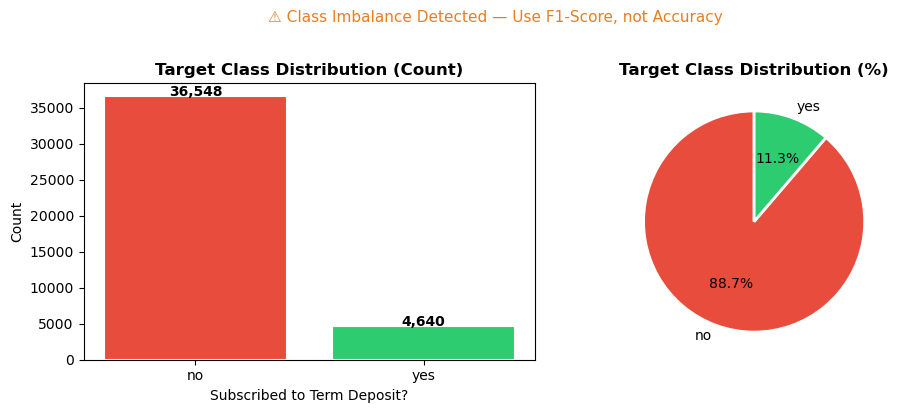

In [11]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print('Target Distribution:')
print(pd.DataFrame({'Count': target_counts, 'Percentage': target_pct.round(2)}))
print(f'\nImbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1  (no:yes)')

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
colors = ['#e74c3c', '#2ecc71']
ax1.bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Target Class Distribution (Count)', fontweight='bold')
ax1.set_xlabel('Subscribed to Term Deposit?')
ax1.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax1.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
ax2.pie(target_counts.values, labels=target_counts.index, colors=colors,
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Target Class Distribution (%)', fontweight='bold')

plt.suptitle('⚠️ Class Imbalance Detected — Use F1-Score, not Accuracy', 
             fontsize=11, color='#e67e22', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

---
## 1.3 — Numeric Feature Distributions
### 📚 Concept: Why plot distributions?


Numeric columns (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


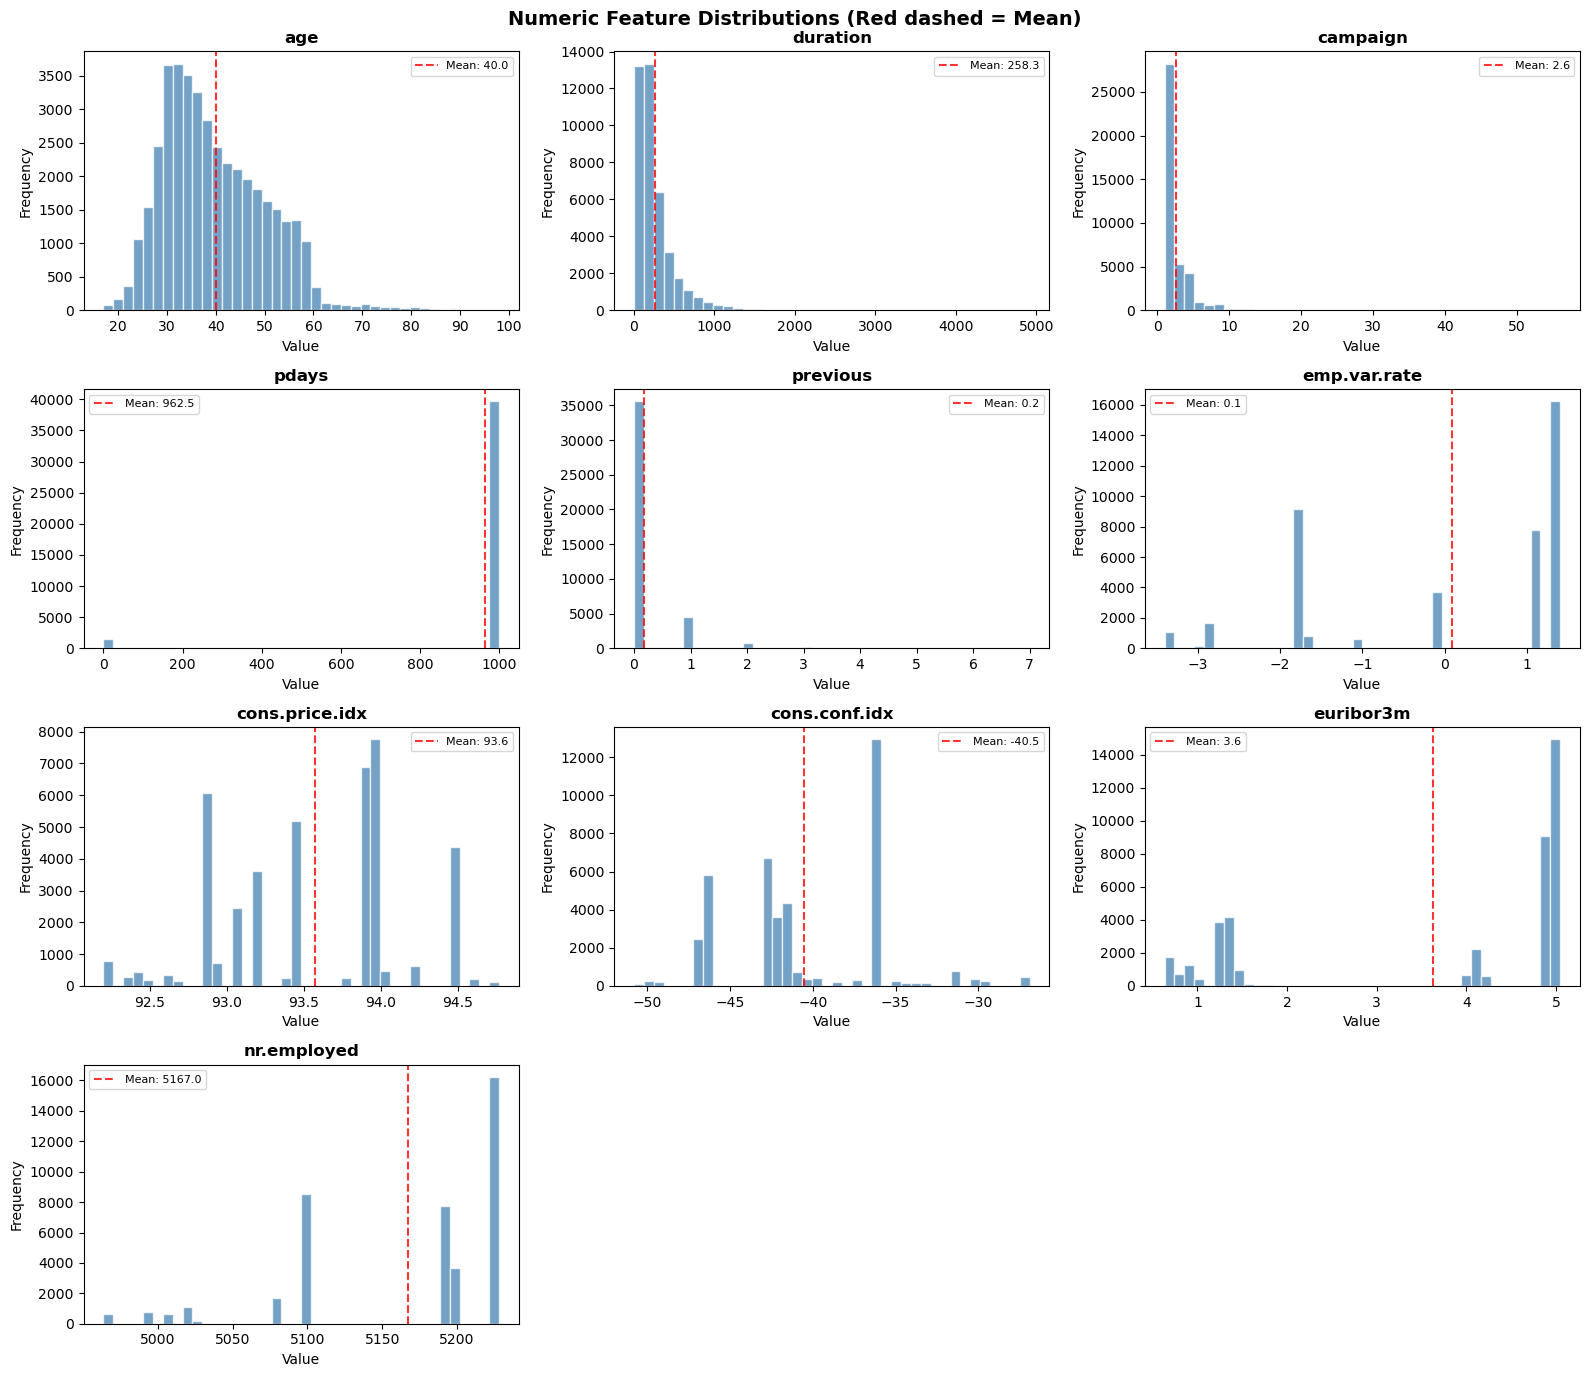

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Numeric columns ({len(num_cols)}): {num_cols}')

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    # Add mean line
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', alpha=0.8, label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions (Red dashed = Mean)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_distributions.png', bbox_inches='tight')
plt.show()

## 1.4 — Correlation Analysis
### 📚 Concept: Correlation Heatmap

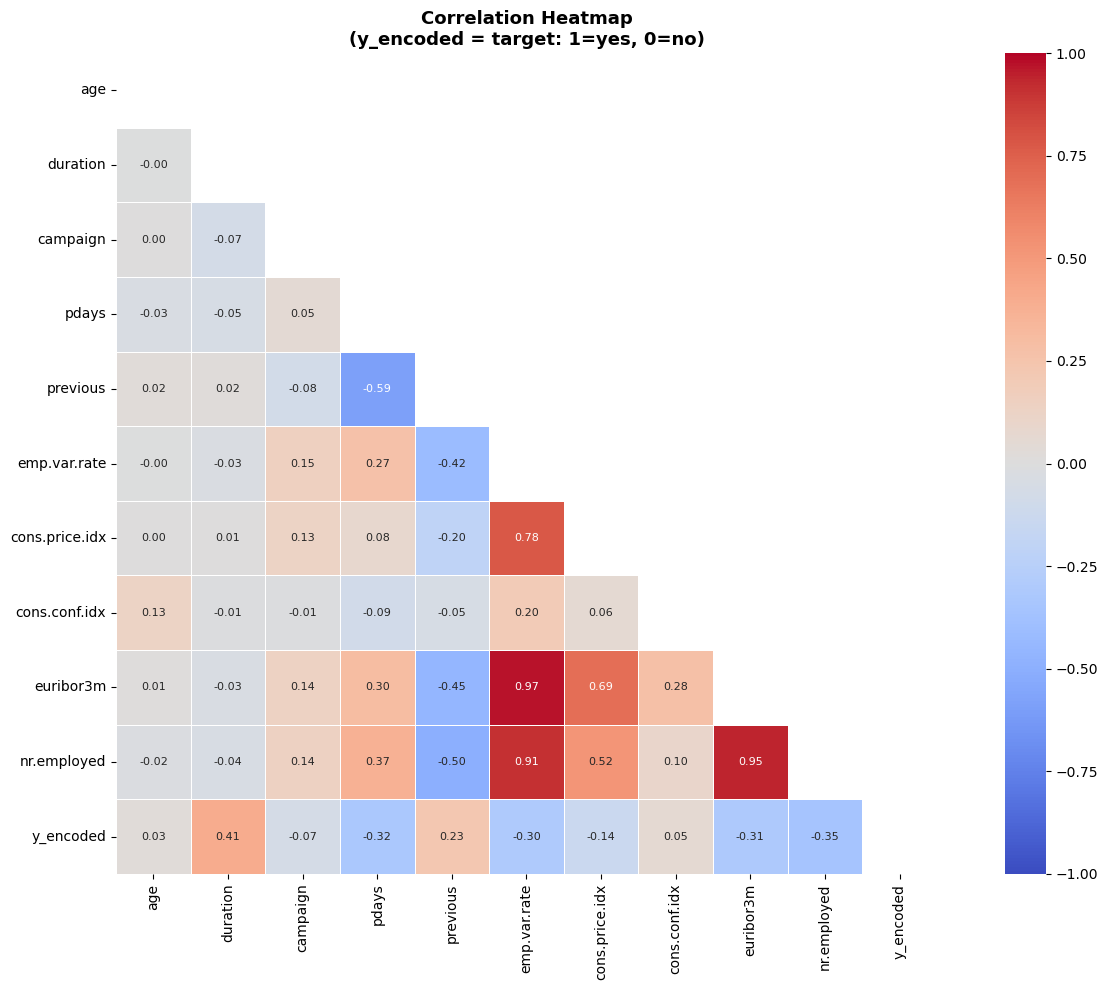


📊 Features most correlated with target (y_encoded):
duration          0.405
previous          0.230
cons.conf.idx     0.055
age               0.030
campaign         -0.066
cons.price.idx   -0.136
emp.var.rate     -0.298
euribor3m        -0.308
pdays            -0.325
nr.employed      -0.355


In [15]:
# Encode target temporarily for correlation
df_corr = df.copy()
df_corr['y_encoded'] = (df_corr['y'] == 'yes').astype(int)

corr_matrix = df_corr[num_cols + ['y_encoded']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Only show lower triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap\n(y_encoded = target: 1=yes, 0=no)', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print features most correlated with target
print('\n📊 Features most correlated with target (y_encoded):')
target_corr = corr_matrix['y_encoded'].drop('y_encoded').sort_values(ascending=False)
print(target_corr.round(3).to_string())

---
## 1.5 — Categorical Feature Analysis
### 📚 Concept: Subscription Rate by Category

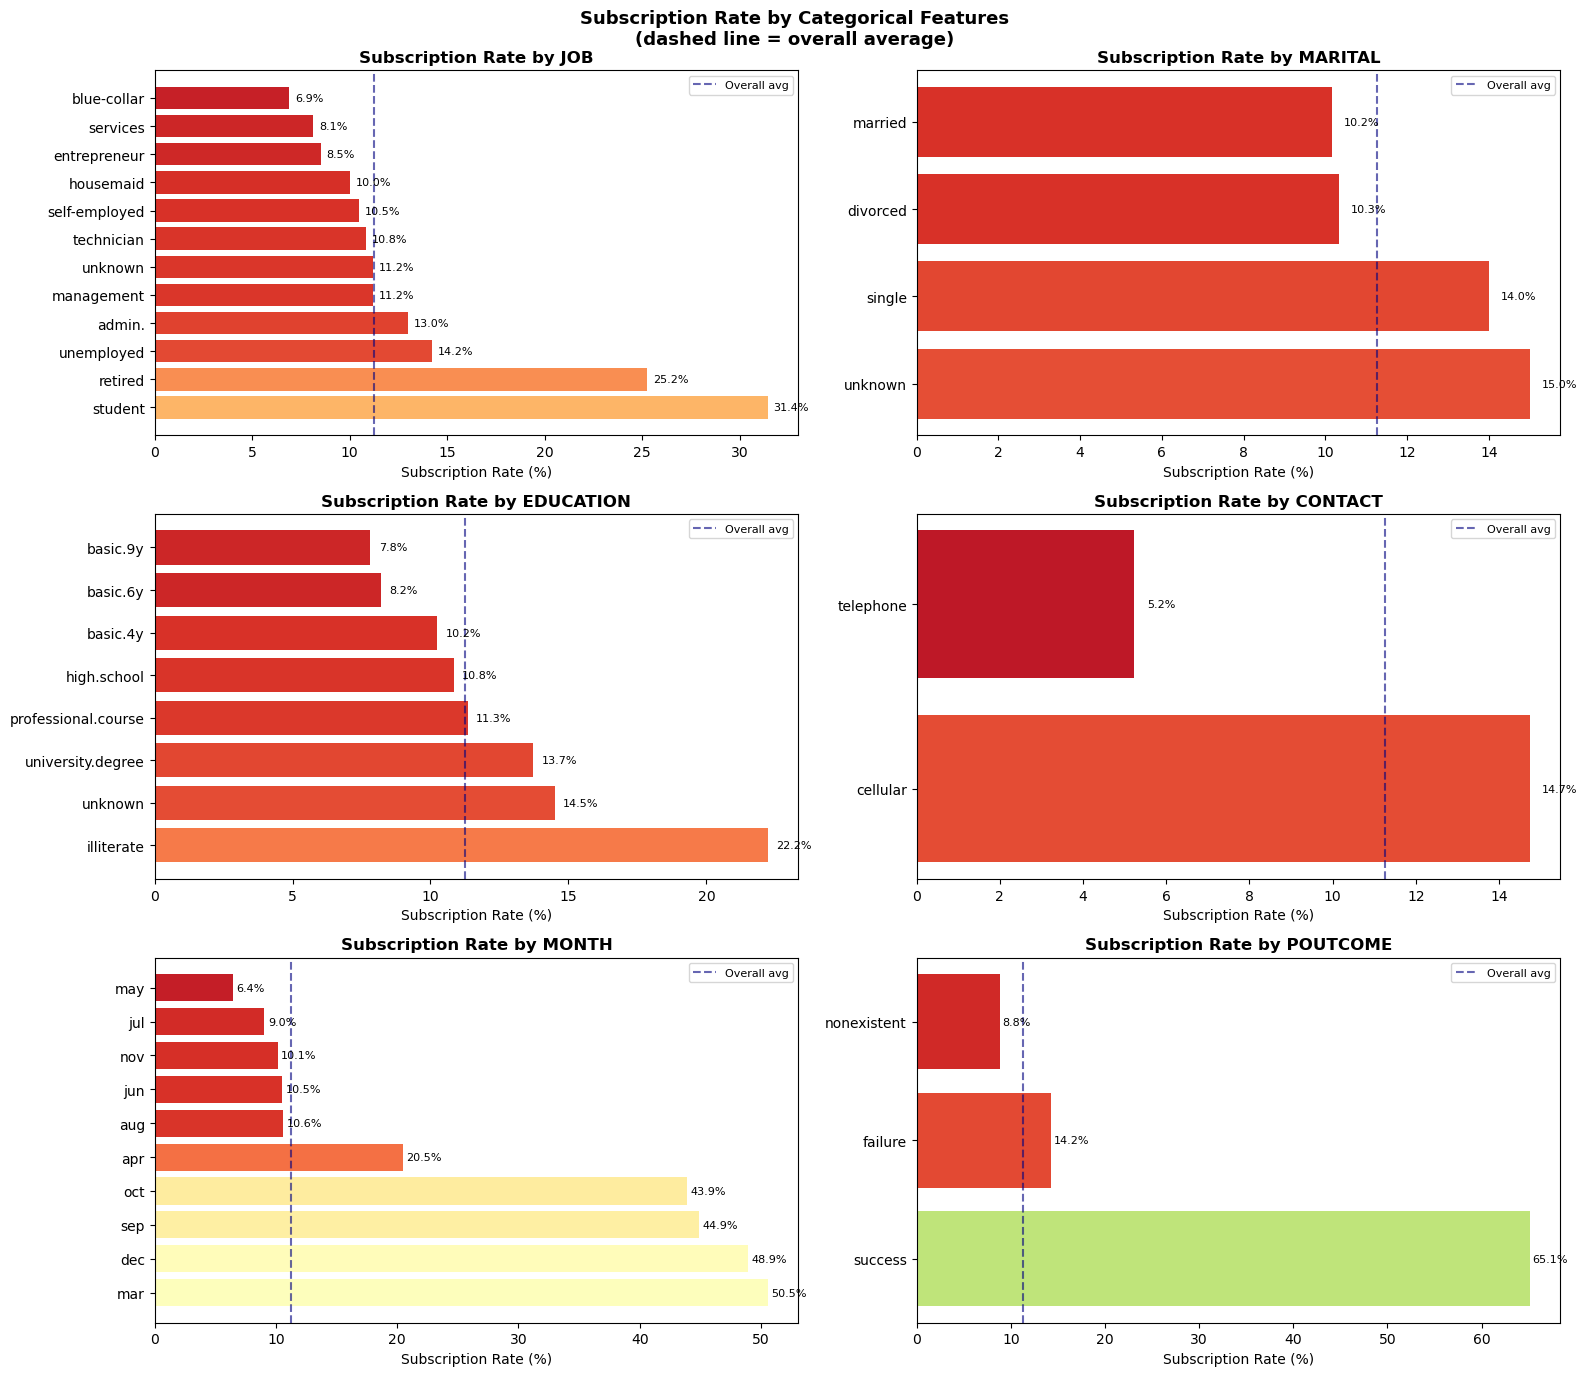

In [17]:
cat_features = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Calculate subscription rate per category
    rate = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)
    
    bars = axes[i].barh(rate.index, rate.values, color=plt.cm.RdYlGn(rate.values / 100))
    axes[i].set_title(f'Subscription Rate by {col.upper()}', fontweight='bold')
    axes[i].set_xlabel('Subscription Rate (%)')
    axes[i].axvline(x=df['y'].value_counts(normalize=True)['yes'] * 100, 
                    color='navy', linestyle='--', alpha=0.6, label='Overall avg')
    axes[i].legend(fontsize=8)
    
    # Add value labels
    for bar, val in zip(bars, rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2, 
                    f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle('Subscription Rate by Categorical Features\n(dashed line = overall average)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight')
plt.show()

In [18]:

print('📋 EDA SUMMARY — KEY FINDINGS')

yes_pct = (df['y'] == 'yes').mean() * 100
print(f'\n1. DATASET: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}')
print(f'\n2. TARGET IMBALANCE: {yes_pct:.1f}% YES vs {100-yes_pct:.1f}% NO')
print(f'   → Will use F1-Score + ROC-AUC as primary metrics')
print(f'   → Will use class_weight="balanced" in models')
print(f'\n3. MISSING VALUES: None (NaN) — but some "unknown" in:')
unknown_counts = (df == 'unknown').sum()
for col, count in unknown_counts[unknown_counts > 0].items():
    print(f'   - {col}: {count} unknowns ({count/len(df)*100:.1f}%)')
print(f'\n4. FEATURES TO WATCH:')
print(f'   - duration: Highly correlated with target (but only known after call ends)')
print(f'   - poutcome: Previous campaign outcome is very informative')
print(f'   - month/day_of_week: Contact timing affects subscription rates')
print(f'\n5. NEXT STEP: Encode categorical features → train models')


📋 EDA SUMMARY — KEY FINDINGS

1. DATASET: 41,188 rows × 21 columns
   Numeric: 10 | Categorical: 11

2. TARGET IMBALANCE: 11.3% YES vs 88.7% NO
   → Will use F1-Score + ROC-AUC as primary metrics
   → Will use class_weight="balanced" in models

3. MISSING VALUES: None (NaN) — but some "unknown" in:
   - job: 330 unknowns (0.8%)
   - marital: 80 unknowns (0.2%)
   - education: 1731 unknowns (4.2%)
   - default: 8597 unknowns (20.9%)
   - housing: 990 unknowns (2.4%)
   - loan: 990 unknowns (2.4%)

4. FEATURES TO WATCH:
   - duration: Highly correlated with target (but only known after call ends)
   - poutcome: Previous campaign outcome is very informative
   - month/day_of_week: Contact timing affects subscription rates

5. NEXT STEP: Encode categorical features → train models


---
# STEP 2: Encode Categorical Features

In [20]:
df_encoded = df.copy()

# --- 2a. Encode Target Variable ---
# Binary: yes → 1, no → 0 (Label Encoding is appropriate here)
df_encoded['y'] = (df_encoded['y'] == 'yes').astype(int)
print('Target encoded: yes=1, no=0')
print(df_encoded['y'].value_counts(), '\n')

# --- 2b. Encode Binary Categorical Columns ---
# Columns with only 2 meaningful values → Label Encode directly
binary_cols = ['default', 'housing', 'loan']
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}  # -1 for unknown

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)
    print(f'{col}: {df_encoded[col].unique()}')

# --- 2c. One-Hot Encode Nominal Categorical Columns ---
nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']

df_encoded = pd.get_dummies(
    df_encoded, 
    columns=nominal_cols, 
    drop_first=True,      # Avoid dummy variable trap
    dtype=int             # Use int instead of bool
)

print(f'\n✅ After encoding: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns')
print(f'   (was {df.shape[1]} columns before encoding — added {df_encoded.shape[1] - df.shape[1]} dummy columns)')
print(f'\nAll dtypes are now numeric: {df_encoded.dtypes.unique()}')
df_encoded.head(3)

Target encoded: yes=1, no=0
y
0    36548
1     4640
Name: count, dtype: int64 

default: [ 0 -1  1]
housing: [ 0  1 -1]
loan: [ 0  1 -1]

✅ After encoding: 41,188 rows × 51 columns
   (was 21 columns before encoding — added 30 dummy columns)

All dtypes are now numeric: [dtype('int64') dtype('float64')]


,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,0,0,0,261,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
1,57,-1,0,0,149,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0
2,37,0,1,0,226,1,999,0,1.1,93.994,...,1,0,0,0,1,0,0,0,1,0


In [21]:
# --- Separate Features (X) and Target (y) ---
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f'Features (X): {X.shape}  |  Target (y): {y.shape}')

# --- Train/Test Split ---
# stratify=y → ensures same class ratio in train and test sets (important with imbalanced data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # Reproducibility
    stratify=y           # Preserve class ratio in both splits
)

print(f'\nTrain set: {X_train.shape[0]:,} rows')
print(f'Test set:  {X_test.shape[0]:,} rows')
print(f'\nClass distribution in train: {y_train.value_counts().to_dict()}')
print(f'Class distribution in test:  {y_test.value_counts().to_dict()}')

# --- Feature Scaling (for Logistic Regression) ---
# WHY SCALE?
# Logistic Regression uses gradient descent — if features are on very different scales,
# the algorithm converges slowly or gives biased coefficients.
# StandardScaler: X_scaled = (X - mean) / std  → mean=0, std=1 for each feature
# NOTE: Fit ONLY on train set, then transform both train and test
# (If you fit on test too, you're leaking test info into training — data leakage!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + Transform on train
X_test_scaled  = scaler.transform(X_test)         # Transform only on test

print(f'\n✅ Scaling done. Train mean ≈ {X_train_scaled.mean():.4f} (should be ~0)')
print(f'   Train std  ≈ {X_train_scaled.std():.4f} (should be ~1)')

Features (X): (41188, 50)  |  Target (y): (41188,)

Train set: 32,950 rows
Test set:  8,238 rows

Class distribution in train: {0: 29238, 1: 3712}
Class distribution in test:  {0: 7310, 1: 928}

✅ Scaling done. Train mean ≈ 0.0000 (should be ~0)
   Train std  ≈ 1.0000 (should be ~1)


# STEP 3: Train Models

In [23]:
# --- Model 1: Logistic Regression ---
# Uses SCALED data (X_train_scaled)
# max_iter=1000 → increase from default 100 to ensure convergence
lr_model = LogisticRegression(
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000,
    random_state=42,
    C=1.0                     # Regularization: C = 1/λ, smaller C = stronger regularization
)
lr_model.fit(X_train_scaled, y_train)
print('✅ Logistic Regression trained')
print(f'   Converged in: {lr_model.n_iter_[0]} iterations')
print(f'   Number of features: {lr_model.n_features_in_}')

# --- Model 2: Random Forest ---
# Uses UNSCALED data (X_train) — trees don't need scaling!
rf_model = RandomForestClassifier(
    n_estimators=100,         # 100 trees
    max_depth=10,             # Limit depth to prevent overfitting
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)
rf_model.fit(X_train, y_train)
print('\n✅ Random Forest trained')
print(f'   Number of trees: {rf_model.n_estimators}')
print(f'   Number of features: {rf_model.n_features_in_}')

# Quick check: training accuracy (not what we use for final eval)
print(f'\n📊 Quick Training Accuracy (for sanity check only):')
print(f'   Logistic Regression: {lr_model.score(X_train_scaled, y_train):.4f}')
print(f'   Random Forest:       {rf_model.score(X_train, y_train):.4f}')
print(f'\n⚠️ Note: High training accuracy can indicate overfitting.')
print(f'   Always evaluate on TEST set (done in Step 4).')

✅ Logistic Regression trained
   Converged in: 50 iterations
   Number of features: 50

✅ Random Forest trained
   Number of trees: 100
   Number of features: 50

📊 Quick Training Accuracy (for sanity check only):
   Logistic Regression: 0.8593
   Random Forest:       0.8735

⚠️ Note: High training accuracy can indicate overfitting.
   Always evaluate on TEST set (done in Step 4).


---
# STEP 4: Evaluate Models
## 📚 Concept Notes — Evaluation Metrics for Classification

### The Confusion Matrix
```
                  Predicted: NO    Predicted: YES
Actual: NO    |      TN          |      FP         |
Actual: YES   |      FN          |      TP         |
```
- **TP** (True Positive): Predicted YES, Actually YES ✅
- **TN** (True Negative): Predicted NO, Actually NO ✅
- **FP** (False Positive): Predicted YES, Actually NO ❌ (Type I Error)
- **FN** (False Negative): Predicted NO, Actually YES ❌ (Type II Error)

### Derived Metrics:
| Metric | Formula | Meaning |
|---|---|---|
| Precision | TP / (TP + FP) | Of those we predicted YES, how many actually subscribed? |
| Recall | TP / (TP + FN) | Of actual subscribers, how many did we correctly identify? |
| F1-Score | 2 × P × R / (P + R) | Harmonic mean — balances Precision & Recall |
| ROC-AUC | Area under ROC curve | How well does the model distinguish classes? (1.0 = perfect) |

In [26]:
# --- Predictions ---
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay

# Probability scores (needed for ROC curve)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]  # Prob of class 1
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# --- Classification Report ---
print('=' * 55)
print('📊 LOGISTIC REGRESSION — Classification Report')
print('=' * 55)
print(classification_report(y_test, lr_preds, target_names=['No (0)', 'Yes (1)']))

print('=' * 55)
print('📊 RANDOM FOREST — Classification Report')
print('=' * 55)
print(classification_report(y_test, rf_preds, target_names=['No (0)', 'Yes (1)']))

# --- F1 Score Summary ---
lr_f1 = f1_score(y_test, lr_preds)
rf_f1 = f1_score(y_test, rf_preds)
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print('\n📈 METRIC COMPARISON:')
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1-Score (class 1)': [f'{lr_f1:.4f}', f'{rf_f1:.4f}'],
    'ROC-AUC': [f'{lr_auc:.4f}', f'{rf_auc:.4f}']
})
print(comparison.to_string(index=False))

📊 LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

      No (0)       0.99      0.86      0.92      7310
     Yes (1)       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

📊 RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      No (0)       0.99      0.86      0.92      7310
     Yes (1)       0.46      0.93      0.61       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.77      8238
weighted avg       0.93      0.87      0.89      8238


📈 METRIC COMPARISON:
              Model F1-Score (class 1) ROC-AUC
Logistic Regression             0.6036  0.9438
      Random Forest             0.6124  0.9497


# STEP 5: SHAP Explanations


In [29]:
# Run: pip install shap 
import shap

# Create SHAP explainer for Random Forest
# TreeExplainer is optimized for tree-based models (faster than KernelExplainer)
print('Creating SHAP TreeExplainer for Random Forest...')
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test set
# We use first 100 rows only for speed (full test set can take a while)
X_test_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, shap_values is a list of 2 arrays
# shap_values[1] = SHAP values for class 1 (subscribed = YES)
shap_vals_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

print(f'SHAP values shape: {shap_vals_class1.shape}')
print(f'Each row = one prediction, each column = one feature')
print('✅ SHAP explainer ready!')

Creating SHAP TreeExplainer for Random Forest...
SHAP values shape: (100, 50)
Each row = one prediction, each column = one feature
✅ SHAP explainer ready!


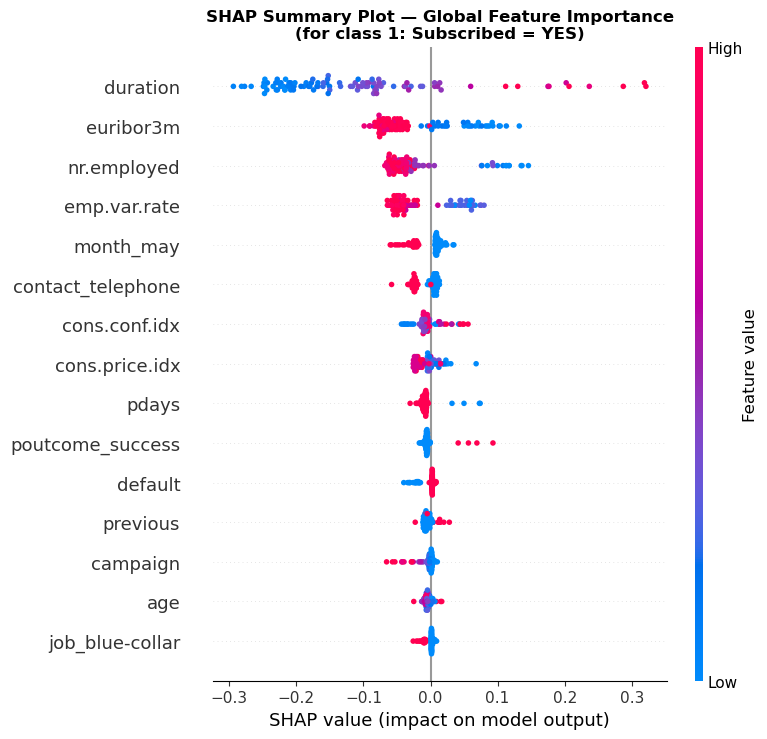

In [31]:
# ============================================================
# SHAP: GLOBAL FEATURE IMPORTANCE (Summary Plot)
# ============================================================
# Shows which features matter MOST across ALL predictions
# Color = feature value (red=high, blue=low)
# X-axis = SHAP value (impact on prediction)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_class1, X_test_sample, show=False, max_display=15)
plt.title('SHAP Summary Plot — Global Feature Importance\n(for class 1: Subscribed = YES)', 
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

In [33]:
# ============================================================
# SHAP: INDIVIDUAL PREDICTIONS — 5 Customers
# ============================================================
# We explain 5 specific customers: why did the model predict what it predicted?

# Select 5 diverse examples (some predicted yes, some no)
predicted_yes_idx = np.where(rf_model.predict(X_test_sample) == 1)[0][:3]
predicted_no_idx  = np.where(rf_model.predict(X_test_sample) == 0)[0][:2]
sample_indices = np.concatenate([predicted_yes_idx, predicted_no_idx])

print('=== SHAP Force Plots: 5 Individual Predictions ===')
print('(Red arrows = push toward YES, Blue arrows = push toward NO)\n')

for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx]
    predicted = rf_model.predict(X_test_sample.iloc[[idx]])[0]
    prob = rf_model.predict_proba(X_test_sample.iloc[[idx]])[0][1]
    
    print(f'--- Customer #{i+1} (Test row {idx}) ---')
    print(f'   Actual: {"YES" if actual==1 else "NO"} | Predicted: {"YES" if predicted==1 else "NO"} | P(yes)={prob:.3f}')
    print(f'   Correct: {"✅" if actual==predicted else "❌"}')
    
    # Show top 5 SHAP drivers for this prediction
    customer_shap = pd.Series(shap_vals_class1[idx], index=X_test_sample.columns)
    top5 = customer_shap.abs().nlargest(5).index
    print('   Top 5 SHAP drivers:')
    for feat in top5:
        sv = customer_shap[feat]
        fv = X_test_sample.iloc[idx][feat]
        direction = '↑ pushed toward YES' if sv > 0 else '↓ pushed toward NO'
        print(f'   {feat:30s}: SHAP={sv:+.4f} (value={fv:.2f}) → {direction}')
    print()

# Waterfall plot for one customer (visually appealing for report/README)
customer_to_explain = sample_indices[0]
print(f'\n📊 Detailed Waterfall Plot: Customer #{sample_indices[0]}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_class1[customer_to_explain],
        base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data=X_test_sample.iloc[customer_to_explain].values,
        feature_names=X_test_sample.columns.tolist()
    ),
    max_display=12,
    show=True
)

=== SHAP Force Plots: 5 Individual Predictions ===
(Red arrows = push toward YES, Blue arrows = push toward NO)

--- Customer #1 (Test row 1) ---
   Actual: NO | Predicted: YES | P(yes)=0.502
   Correct: ❌
   Top 5 SHAP drivers:
   duration                      : SHAP=-0.2492 (value=100.00) → ↓ pushed toward NO
   nr.employed                   : SHAP=+0.0929 (value=5076.20) → ↑ pushed toward YES
   emp.var.rate                  : SHAP=+0.0626 (value=-2.90) → ↑ pushed toward YES
   euribor3m                     : SHAP=+0.0613 (value=1.26) → ↑ pushed toward YES
   month_may                     : SHAP=+0.0223 (value=0.00) → ↑ pushed toward YES

--- Customer #2 (Test row 2) ---
   Actual: NO | Predicted: YES | P(yes)=0.578
   Correct: ❌
   Top 5 SHAP drivers:
   duration                      : SHAP=-0.1800 (value=131.00) → ↓ pushed toward NO
   nr.employed                   : SHAP=+0.1120 (value=4991.60) → ↑ pushed toward YES
   euribor3m                     : SHAP=+0.1038 (value=0.81) → ↑

TypeError: only 0-dimensional arrays can be converted to Python scalars